# Semana 9: Laboratorio de Análisis Exploratorio de Datos (EDA)

**Curso:** Introducción a Business Analytics  
**Tema:** EDA - Análisis Univariado y Multivariado
**Docente:** Ana Rocío Cárdenas Maita

---

## ¿Qué es el Análisis Exploratorio de Datos?

El **Análisis Exploratorio de Datos (EDA)** es el proceso de investigar un dataset antes de aplicar modelos o sacar conclusiones. Los objetivos principales son:

- Entender la **estructura** del dataset (dimensiones, tipos de datos)
- Detectar **valores atípicos** (outliers) y **datos faltantes**
- Comprender la **distribución** de cada variable
- Descubrir **relaciones** entre variables

El EDA se divide en dos grandes enfoques:

| Tipo | ¿Qué analiza? | Método No gráfico | Método gráfico | 
|------|--------------|----------------------|-------------------------| 
| **Univariado** | Una sola variable a la vez | Variable Categórica: Representación tabular de frecuencia. | Variable Categórica: Bar Plots | 
|                |                            | Variable Cuantitativa: Ubicación (promedio, mediana), Dispersión (dev, varianza, std dev, rango, percentil) | Variable Cuantitativa: Histogramas, Boxplots| 
| **Multivariado** | Relaciones entre dos o más variables   | Dos variables Categóricas: Tabulación Cruzada | Scatter plots, Mapa de calor de correlación, (Correlation Heatmap), pair plots|
|                  |                                        | Dos o más variables Cuantitativas: Correlación, Covarianza |   |

---

## El Dataset Iris

El dataset **Iris** es uno de los más clásicos en Machine Learning y estadística. Fue introducido por el biólogo y estadístico **Ronald Fisher** en 1936.

Contiene **150 muestras** de flores de iris, divididas en 3 especies:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Para cada muestra se midieron **4 características** (features):

| Variable | Descripción | Unidad |
|----------|-------------|--------|
| `sepal_length` | Largo del sépalo | cm |
| `sepal_width`  | Ancho del sépalo  | cm |
| `petal_length` | Largo del pétalo  | cm |
| `petal_width`  | Ancho del pétalo  | cm |
| `species`      | Especie de la flor | categórica |

> 💡 **¿Por qué Iris?** Es un dataset pequeño, limpio y con patrones claros, ideal para aprender técnicas de análisis y clasificación.

---
## 0. Importación de librerías

In [4]:
# Librerías estándar de análisis de datos
import pandas as pd          # Manipulación de datos en tablas (DataFrames)
import numpy as np           # Operaciones numéricas y vectorizadas

# Librerías de visualización
import matplotlib.pyplot as plt   # Gráficos base
import seaborn as sns             # Gráficos estadísticos de alto nivel (sobre matplotlib)

# Librería con datasets clásicos de ML
from sklearn.datasets import load_iris

# Para análisis estadístico adicional
from scipy import stats

# Configuración de estilo de gráficos
sns.set_theme(style='whitegrid', palette='Set2')  # Tema limpio con paleta de colores
plt.rcParams['figure.figsize'] = (10, 5)          # Tamaño por defecto de las figuras

print('Librerías importadas correctamente...')

ModuleNotFoundError: No module named 'pandas'

---
## 1. Carga y primera inspección del dataset

In [ ]:
# Cargamos el dataset Iris desde sklearn y lo convertimos a un DataFrame de pandas
iris_raw = load_iris()

# iris_raw es un objeto tipo Bunch (similar a un diccionario)
# .data contiene la matriz de features, .target los labels numéricos
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)

# Agregamos la columna de especie como texto (más legible que números 0, 1, 2)
df['species'] = pd.Categorical(
    [iris_raw.target_names[t] for t in iris_raw.target]
)

# Renombramos columnas para que sean más cortas y cómodas de usar
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)  # Mostramos las primeras 10 filas

Dataset cargado: 150 filas × 5 columnas


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
# .info() muestra: número de filas, tipo de dato de cada columna y valores no nulos
# Es el primer chequeo para detectar datos faltantes y tipos incorrectos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [ ]:
# Verificamos cuántos valores nulos hay por columna
# En Iris no hay nulos, pero este paso es esencial en datasets reales
print('Valores nulos por columna:')
print(df.isnull().sum())

print(f'\nClases y cantidad de muestras por clase:')
print(df['species'].value_counts())

Valores nulos por columna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Clases y cantidad de muestras por clase:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## 2. Análisis Univariado

### Repaso teórico

El **análisis univariado** estudia **una variable a la vez**, sin considerar relaciones con otras. Sus herramientas principales son:

#### Estadísticos descriptivos

| Medida | Símbolo | Descripción |
|--------|---------|-------------|
| **Media** | $\bar{x}$ | Promedio aritmético: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ |
| **Mediana** | $\tilde{x}$ | Valor central cuando los datos están ordenados |
| **Desviación estándar** | $\sigma$ | Dispersión promedio respecto a la media |
| **Varianza** | $\sigma^2$ | Dispersión al cuadrado: $\sigma^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ |
| **Asimetría (skewness)** | — | Qué tan simétrica es la distribución |
| **Curtosis (kurtosis)** | — | Qué tan "puntiaguda" o "plana" es la distribución |

#### Gráficos
- **Histograma**: muestra la frecuencia de valores en intervalos (bins)
- **Boxplot (caja y bigotes)**: muestra Q1, mediana, Q3 e identifica outliers
- **KDE (Kernel Density Estimate)**: versión suavizada del histograma, estima la función de densidad de probabilidad



In [ ]:
# .describe() calcula automáticamente los principales estadísticos descriptivos
# para todas las columnas numéricas: count, mean, std, min, cuartiles y max
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [ ]:
# Calculamos estadísticos adicionales que .describe() no incluye
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

stats_extra = pd.DataFrame({
    'skewness': df[features].skew(),    # Asimetría: >0 cola derecha, <0 cola izquierda
    'kurtosis': df[features].kurtosis() # Curtosis: >0 más puntiaguda que normal, <0 más plana
})

print('Asimetría y Curtosis:')
print(stats_extra.round(3))

print('\n Referencia:')
print('  Skewness ≈ 0   → distribución simétrica')
print('  Skewness > 0   → cola hacia la derecha (sesgo positivo)')
print('  Kurtosis ≈ 0   → similar a distribución normal (mesocúrtica)')
print('  Kurtosis > 0   → más concentrada, colas pesadas (leptocúrtica)')

Asimetría y Curtosis:
              skewness  kurtosis
sepal_length     0.315    -0.552
sepal_width      0.319     0.228
petal_length    -0.275    -1.402
petal_width     -0.103    -1.341

 Referencia:
  Skewness ≈ 0   → distribución simétrica
  Skewness > 0   → cola hacia la derecha (sesgo positivo)
  Kurtosis ≈ 0   → similar a distribución normal (mesocúrtica)
  Kurtosis > 0   → más concentrada, colas pesadas (leptocúrtica)


### 2.1 Histogramas con KDE

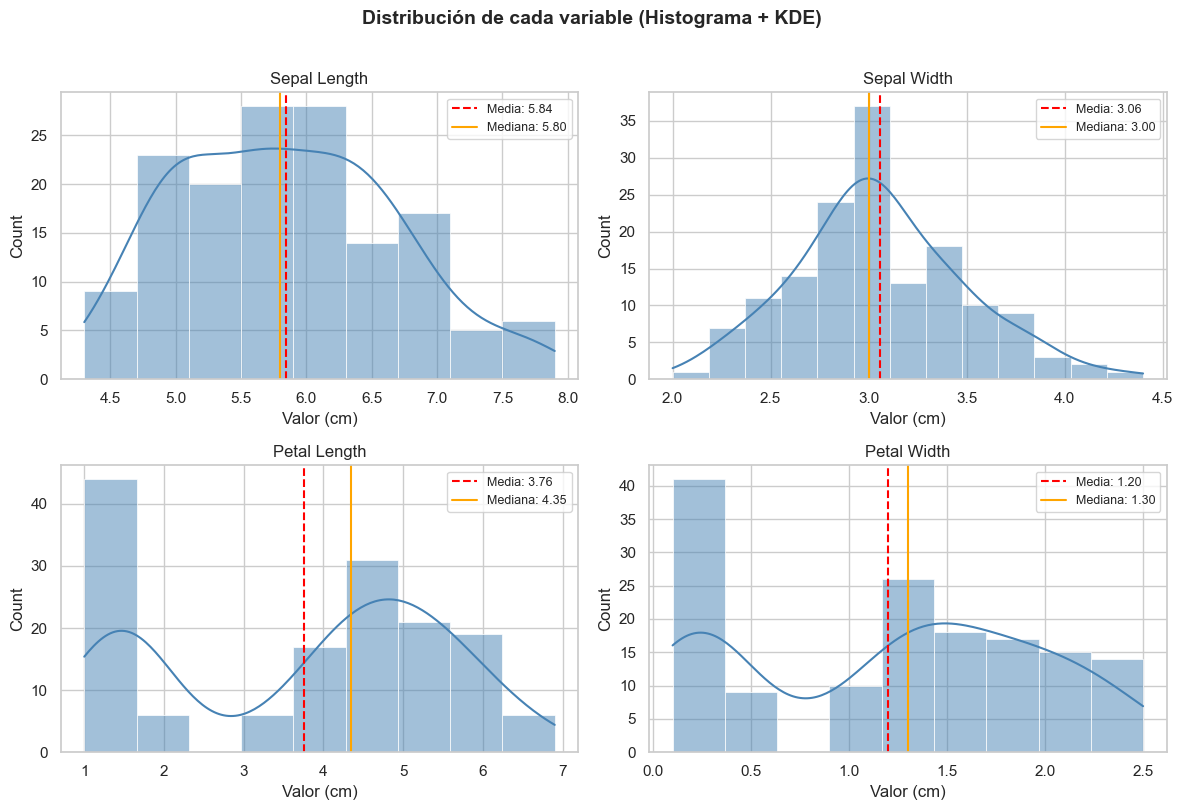

In [ ]:
# Creamos una figura con 4 subplots (uno por feature)
# Cada subplot muestra el histograma + la curva KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Convertimos la matriz 2x2 en un array 1D para iterar fácilmente

for i, feature in enumerate(features):
    # histplot con kde=True superpone la curva de densidad estimada al histograma
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i],
                 color='steelblue', edgecolor='white', linewidth=0.5)
    
    # Agregamos líneas verticales para media y mediana
    mean_val   = df[feature].mean()
    median_val = df[feature].median()
    axes[i].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana: {median_val:.2f}')
    
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('Valor (cm)')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de cada variable (Histograma + KDE)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Observación: petal_length y petal_width muestran distribuciones bimodales,
# lo que sugiere que las diferentes especies tienen tamaños distintos.

### 2.2 Boxplots — Detección de outliers

#### Regla del boxplot para outliers
Un dato se considera **outlier** si cae fuera del rango:
$$[Q1 - 1.5 \cdot IQR, \quad Q3 + 1.5 \cdot IQR]$$
donde $IQR = Q3 - Q1$ es el rango intercuartílico.

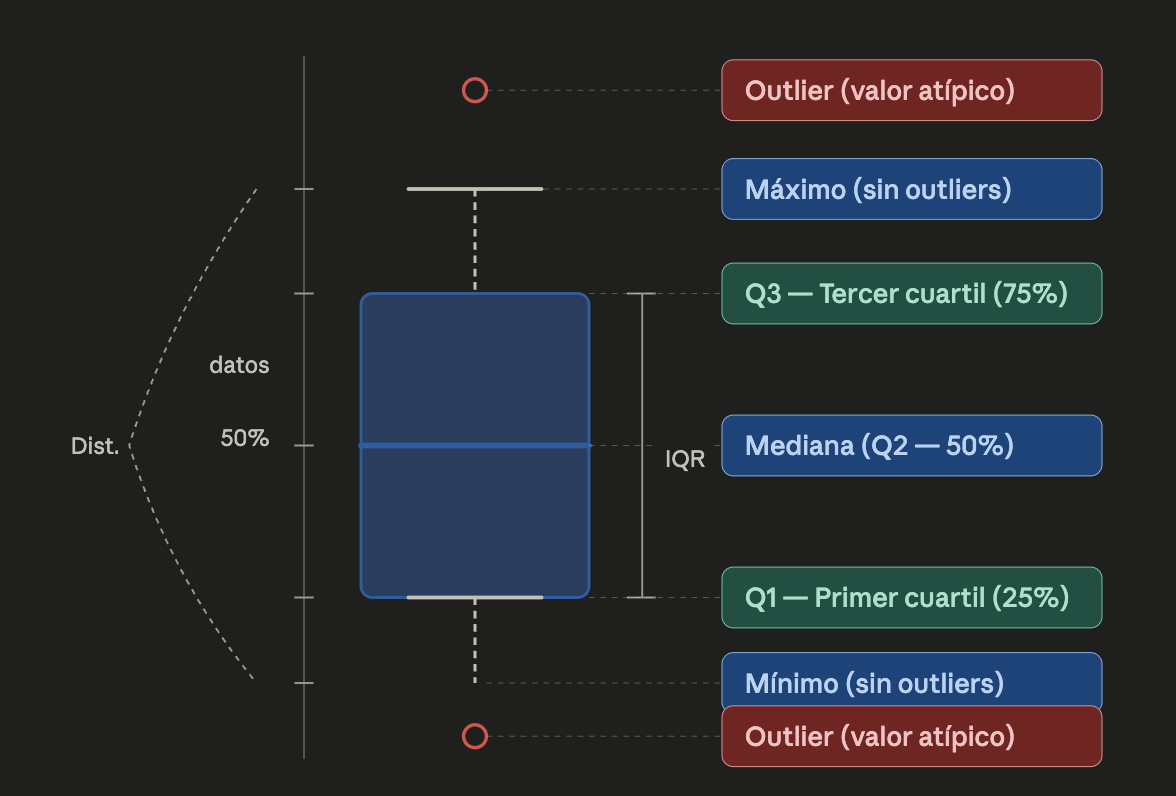

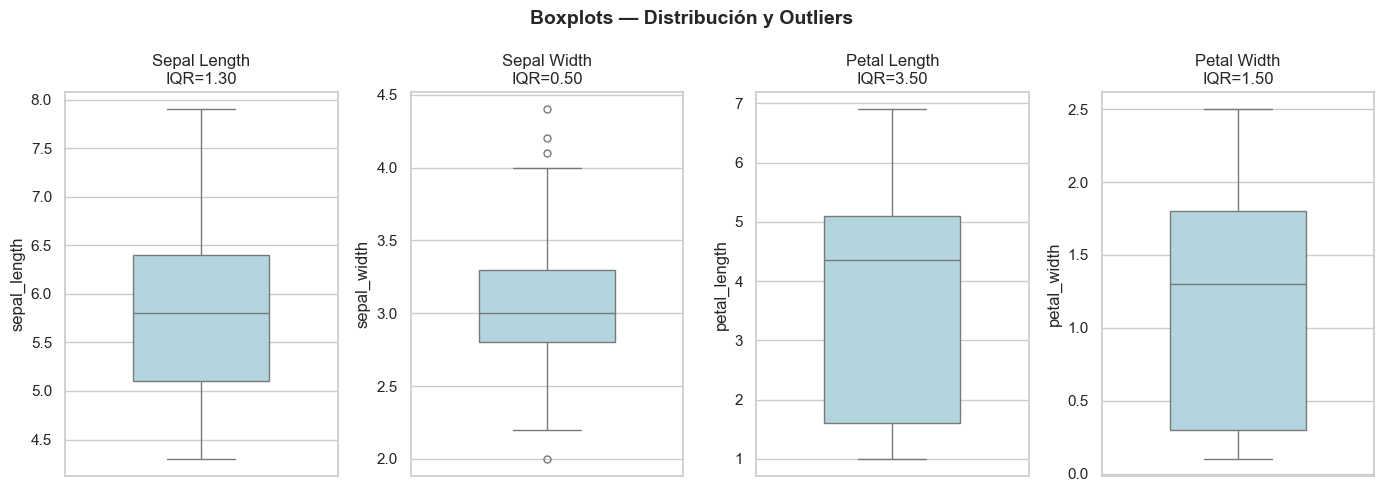

In [ ]:
# El boxplot es ideal para visualizar la dispersión y los outliers de una variable
# Los puntos fuera de los bigotes son candidatos a outliers según la regla IQR

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, feature in enumerate(features):
    sns.boxplot(data=df, y=feature, ax=axes[i], color='lightblue',
                width=0.5, flierprops={'marker': 'o', 'color': 'red', 'markersize': 5})
    
    # Calcular e imprimir el IQR para cada variable
    q1  = df[feature].quantile(0.25)
    q3  = df[feature].quantile(0.75)
    iqr = q3 - q1
    
    axes[i].set_title(f'{feature.replace("_", " ").title()}\nIQR={iqr:.2f}')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — Distribución y Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Identificamos los outliers de forma programática usando la regla de Tukey (1.5 * IQR)
print('🔍 Outliers detectados por variable (regla IQR × 1.5):\n')

for feature in features:
    q1  = df[feature].quantile(0.25)
    q3  = df[feature].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Filtramos las filas donde el valor está fuera de los límites
    outliers = df[(df[feature] < lim_inf) | (df[feature] > lim_sup)]
    print(f'  {feature}: {len(outliers)} outlier(s) → límites [{lim_inf:.2f}, {lim_sup:.2f}]')

🔍 Outliers detectados por variable (regla IQR × 1.5):

  sepal_length: 0 outlier(s) → límites [3.15, 8.35]
  sepal_width: 4 outlier(s) → límites [2.05, 4.05]
  petal_length: 0 outlier(s) → límites [-3.65, 10.35]
  petal_width: 0 outlier(s) → límites [-1.95, 4.05]


### 2.3 Análisis univariado por especie

In [ ]:
# Segmentamos el análisis por especie para ver diferencias entre grupos
# groupby + agg permite calcular múltiples estadísticos a la vez
summary_by_species = df.groupby('species')[features].agg(['mean', 'std', 'min', 'max']).round(2)
print('Estadísticos descriptivos por especie:')
summary_by_species

Estadísticos descriptivos por especie:


/var/folders/jp/qnxl8y2x0v39hxlcr6jxpvj40000gn/T/ipykernel_90156/1476467444.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_by_species = df.groupby('species')[features].agg(['mean', 'std', 'min', 'max']).round(2)


sepal_length                 sepal_width                  \
                   mean   std  min  max        mean   std  min  max   
species                                                               
setosa             5.01  0.35  4.3  5.8        3.43  0.38  2.3  4.4   
versicolor         5.94  0.52  4.9  7.0        2.77  0.31  2.0  3.4   
virginica          6.59  0.64  4.9  7.9        2.97  0.32  2.2  3.8   

           petal_length                 petal_width                  
                   mean   std  min  max        mean   std  min  max  
species                                                              
setosa             1.46  0.17  1.0  1.9        0.25  0.11  0.1  0.6  
versicolor         4.26  0.47  3.0  5.1        1.33  0.20  1.0  1.8  
virginica          5.55  0.55  4.5  6.9        2.03  0.27  1.4  2.5

/var/folders/jp/qnxl8y2x0v39hxlcr6jxpvj40000gn/T/ipykernel_90156/4224254852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
/var/folders/jp/qnxl8y2x0v39hxlcr6jxpvj40000gn/T/ipykernel_90156/4224254852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
/var/folders/jp/qnxl8y2x0v39hxlcr6jxpvj40000gn/T/ipykernel_90156/4224254852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[

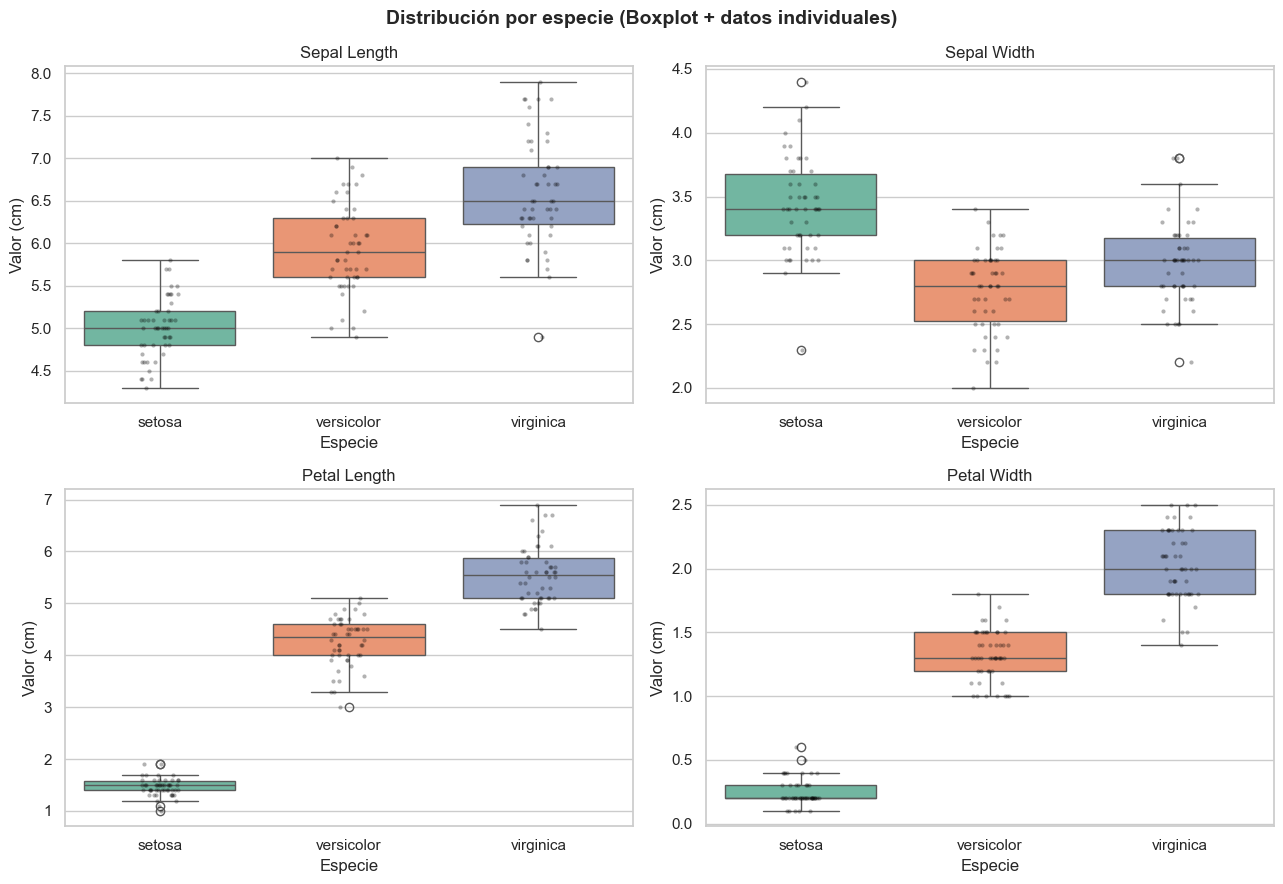

In [ ]:
# Boxplots separados por especie: revelan si las distribuciones difieren entre clases
# Esto es fundamental para entender si una variable tiene poder discriminatorio

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
    sns.stripplot(data=df, x='species', y=feature, ax=axes[i],
                  color='black', alpha=0.3, size=3, jitter=True)  # Puntos individuales superpuestos
    
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Especie')
    axes[i].set_ylabel('Valor (cm)')

plt.suptitle('Distribución por especie (Boxplot + datos individuales)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Observación clave: petal_length y petal_width diferencian muy bien las especies.
# sepal_width tiene mayor solapamiento entre especies.